# Opposing Personas: Activations, Logit Lens & Probes

Analysis of the activation probing experiment: two opposing political personas
(conservative vs progressive) answering 205 MCQs via Dolphin Mistral 24B.

**Sections:** Setup → Answer Analysis → Logit Lens → Activations → Probes → Key Findings

## 1. Setup & Data Loading

Point `RUN_DIR` at the activation probing output directory.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
sns.set_style("whitegrid")

# ── CONFIG: change this path to analyze a different run ─────────────────
RUN_DIR = Path("results/raw/activation_probing_20260304_221155")

# ── Auto-resolve paths (handles running from repo root or analysis/) ────
for base in [Path.cwd(), Path.cwd().parent]:
    if (base / RUN_DIR).exists():
        RUN_DIR = base / RUN_DIR
        break

assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"

# Infer tasks file from metadata
with open(RUN_DIR / "metadata.json") as f:
    _meta = json.load(f)
TASKS_FILE = RUN_DIR.parent.parent.parent / "tasks" / _meta["task_file"]
if not TASKS_FILE.exists():
    for base in [Path.cwd(), Path.cwd().parent]:
        candidate = base / "tasks" / _meta["task_file"]
        if candidate.exists():
            TASKS_FILE = candidate
            break

assert TASKS_FILE.exists(), f"Task file not found: {TASKS_FILE}"

# Model footer for plots
def _model_footer(fig, label, y=-0.04):
    fig.text(0.5, y, label, ha="center", va="top", fontsize=9, color="dimgray")

print(f"Run directory: {RUN_DIR}")
print(f"Tasks file:    {TASKS_FILE}")

In [2]:
# ── Load metadata ───────────────────────────────────────────────────────
with open(RUN_DIR / "metadata.json") as f:
    meta = json.load(f)

MODEL_NAME = meta["model_name"]
N_QUESTIONS = meta["n_questions"]
N_LAYERS = meta["n_layers"]
D_MODEL = meta["d_model"]
PERSONAS = meta["persona_names"]
CHOICES = meta["logit_lens_choice_order"]  # ["A", "B", "C", "D"]
QUESTION_IDS = meta["question_ids"]

P1, P2 = PERSONAS
print(f"Model: {MODEL_NAME}")
print(f"Personas: {P1} vs {P2}")
print(f"Questions: {N_QUESTIONS}, Layers: {N_LAYERS}, d_model: {D_MODEL}")

# ── Load answer tables ──────────────────────────────────────────────────
logits_df = pd.read_csv(RUN_DIR / "answer_logits.csv")
paired_df = pd.read_csv(RUN_DIR / "paired_answers.csv")

# ── Load questions with categories ──────────────────────────────────────
with open(TASKS_FILE) as f:
    questions_raw = json.load(f)
questions_map = {q["question_id"]: q for q in questions_raw}

# Add category info to paired_df
paired_df["category"] = paired_df["question_id"].map(
    lambda qid: questions_map.get(qid, {}).get("category_name", "unknown")
)
paired_df["expected_disagreement"] = paired_df["question_id"].map(
    lambda qid: questions_map.get(qid, {}).get("expected_disagreement", "unknown")
)
# Short category labels
CAT_SHORT = {
    "Category 1: Policy Questions (High disagreement expected)": "Policy (high)",
    "Category 2: Values and Priorities (High disagreement expected)": "Values (high)",
    "Category 3: Ethical Dilemmas (Moderate disagreement expected)": "Ethics (mod)",
    "Category 4: Factual Questions (Agreement expected \u2014 CONTROL)": "Factual (ctrl)",
    "Category 5: Ambiguous/Borderline Questions (Uncertain disagreement \u2014 interesting to analyze)": "Ambiguous",
}
paired_df["cat_short"] = paired_df["category"].map(CAT_SHORT).fillna(paired_df["category"])

# ── Load logit lens tensors ────────────────────────────────────────────
logit_lens = {}
for p in PERSONAS:
    safe = p.replace(" ", "_")
    logit_lens[p] = torch.load(RUN_DIR / f"logit_lens_{safe}.pt", map_location="cpu", weights_only=True)
    print(f"logit_lens[{p}] shape: {logit_lens[p].shape}")  # [n_q, n_layers, 4]

# ── Load activation tensors ────────────────────────────────────────────
activations = {}
for p in PERSONAS:
    safe = p.replace(" ", "_")
    activations[p] = torch.load(RUN_DIR / f"activations_{safe}.pt", map_location="cpu", weights_only=True)
    print(f"activations[{p}] shape: {activations[p].shape}")  # [n_q, n_layers, d_model]

print(f"\nLoaded {N_QUESTIONS} questions, {N_LAYERS} layers, d_model={D_MODEL}")

Model: dphn/Dolphin-Mistral-24B-Venice-Edition
Personas: persona_conservative vs persona_progressive
Questions: 205, Layers: 41, d_model: 5120
logit_lens[persona_conservative] shape: torch.Size([205, 41, 4])
logit_lens[persona_progressive] shape: torch.Size([205, 41, 4])
activations[persona_conservative] shape: torch.Size([205, 41, 5120])
activations[persona_progressive] shape: torch.Size([205, 41, 5120])

Loaded 205 questions, 41 layers, d_model=5120


## 2. Answer Analysis

For each of the 205 political MCQs, both personas (conservative and progressive) pick one of A/B/C/D based on whichever option gets the highest logit at the final layer. We never generate text — we just look at which answer letter the model assigns the most probability to.

**Agreement** = both personas pick the same letter. **Disagreement** = they pick different letters.

The questions are split into 5 categories with different expected disagreement levels:
- **Policy (high)**: concrete policy questions (immigration, policing, etc.) — designed for maximum ideological split
- **Values (high)**: abstract value/priority questions — also high expected disagreement
- **Ethics (mod)**: ethical dilemmas — moderate expected disagreement
- **Factual (ctrl)**: factual questions with objectively correct answers — our control group, should show agreement
- **Ambiguous**: borderline questions where disagreement is uncertain

In [3]:
# ── Overall agreement / disagreement ───────────────────────────────────
n_agree = paired_df["is_agreement"].sum()
n_disagree = paired_df["is_disagreement"].sum()
total = len(paired_df)

print(f"Overall: {n_agree}/{total} agree ({100*n_agree/total:.1f}%), "
      f"{n_disagree}/{total} disagree ({100*n_disagree/total:.1f}%)")

# ── By category ────────────────────────────────────────────────────────
cat_summary = paired_df.groupby("cat_short").agg(
    n=("question_id", "count"),
    n_agree=("is_agreement", "sum"),
    n_disagree=("is_disagreement", "sum"),
).reset_index()
cat_summary["agree_rate"] = (cat_summary["n_agree"] / cat_summary["n"] * 100).round(1)
cat_summary["disagree_rate"] = (cat_summary["n_disagree"] / cat_summary["n"] * 100).round(1)
display(cat_summary)

Overall: 75/205 agree (36.6%), 130/205 disagree (63.4%)


,cat_short,n,n_agree,n_disagree,agree_rate,disagree_rate
0,Ambiguous,36,22,14,61.1,38.9
1,Ethics (mod),36,16,20,44.4,55.6
2,Factual (ctrl),35,35,0,100.0,0.0
3,Policy (high),50,0,50,0.0,100.0
4,Values (high),48,2,46,4.2,95.8


### Agreement rate by category

The stacked bar below shows what fraction of questions each category sees agreement (green) vs disagreement (red). This is a sanity check: if the personas are working, Policy and Values questions should be mostly red, while Factual (control) questions should be mostly green.

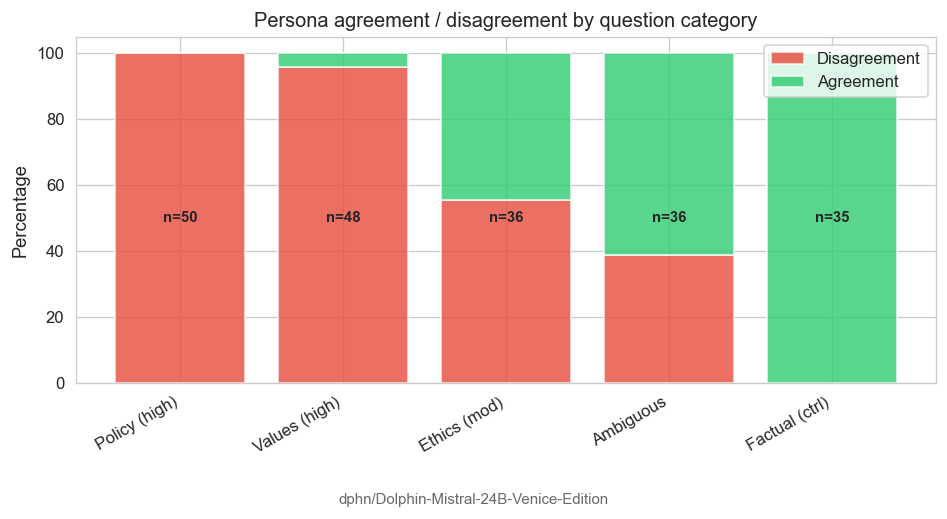

In [4]:
# ── Agreement rate by category (stacked bar chart) ─────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
cats_ordered = cat_summary.sort_values("disagree_rate", ascending=False)
x = range(len(cats_ordered))
ax.bar(x, cats_ordered["disagree_rate"], color="#e74c3c", alpha=0.8, label="Disagreement")
ax.bar(x, cats_ordered["agree_rate"], bottom=cats_ordered["disagree_rate"],
       color="#2ecc71", alpha=0.8, label="Agreement")
ax.set_xticks(x)
ax.set_xticklabels(cats_ordered["cat_short"], rotation=30, ha="right")
ax.set_ylabel("Percentage")
ax.set_title("Persona agreement / disagreement by question category")
ax.legend()
for i, (_, row) in enumerate(cats_ordered.iterrows()):
    ax.text(i, 50, f"n={int(row['n'])}", ha="center", va="center", fontsize=9, fontweight="bold")
ax.set_ylim(0, 105)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Answer letter distributions

How often does each persona pick A, B, C, or D? If the question options are designed so that (say) option A is always the "progressive" answer, we'd see a skew. In practice, options are shuffled, so we're looking for whether one persona is systematically more decisive or scattered than the other.

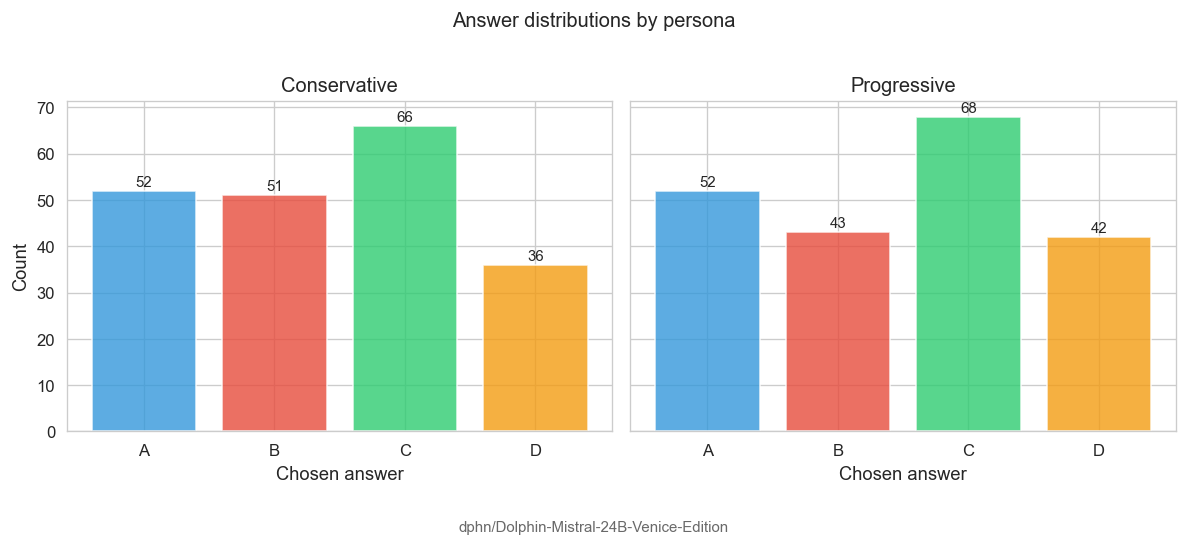

In [5]:
# ── Answer distributions per persona ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, p in zip(axes, PERSONAS):
    sub = logits_df[logits_df["persona"] == p]
    counts = sub["chosen_answer"].value_counts().reindex(CHOICES, fill_value=0)
    ax.bar(CHOICES, counts, color=["#3498db", "#e74c3c", "#2ecc71", "#f39c12"], alpha=0.8)
    ax.set_title(p.replace("persona_", "").title())
    ax.set_xlabel("Chosen answer")
    if ax == axes[0]:
        ax.set_ylabel("Count")
    for i, c in enumerate(CHOICES):
        ax.text(i, counts[c] + 1, str(counts[c]), ha="center", fontsize=9)
fig.suptitle("Answer distributions by persona", y=1.02)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Decisiveness and uncertainty

Two ways to measure how "sure" the model is about its chosen answer:

- **Max probability** (left): the probability assigned to the winning answer (A, B, C, or D). A value near 1.0 means the model was very confident in one option; near 0.25 means it was basically guessing between four options equally.
- **Answer entropy** (right): information-theoretic uncertainty over the four options. Low entropy = confident (all probability mass on one option). High entropy = uncertain (probability spread across options). Max possible entropy for 4 choices is ln(4) = 1.39.

If one persona is systematically more decisive than the other, that's interesting — it could mean the persona prompt is making the model more or less certain about its political stance.

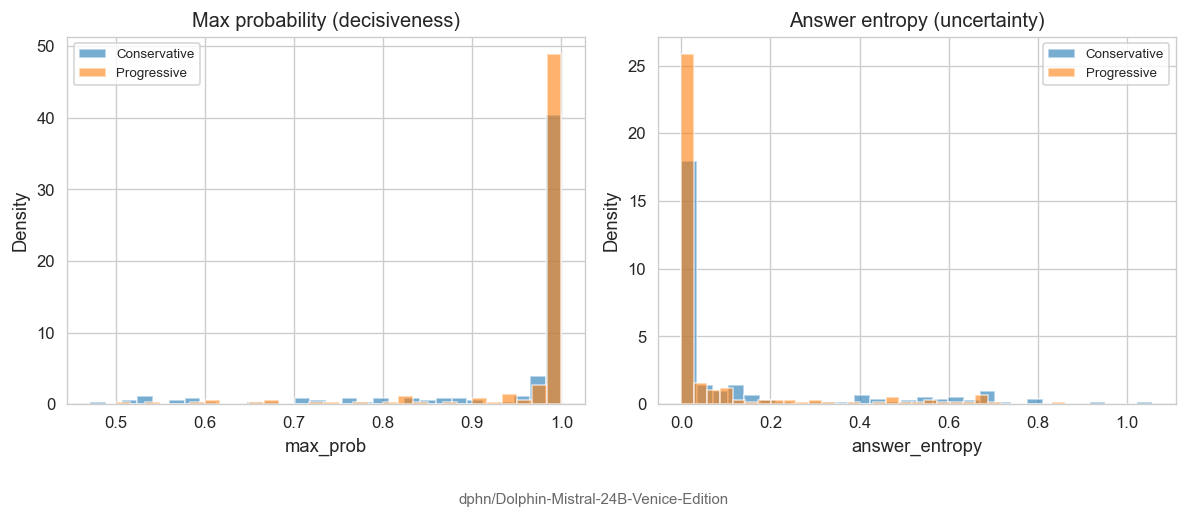

Mean max_prob and answer_entropy per persona:


,max_prob,answer_entropy
persona,,
persona_conservative,0.9408,0.1357
persona_progressive,0.9699,0.0745


In [6]:
# ── Decisiveness: max probability and answer entropy ───────────────────
logits_df["max_prob"] = logits_df[["prob_A", "prob_B", "prob_C", "prob_D"]].max(axis=1)
logits_df["answer_entropy"] = -sum(
    logits_df[f"prob_{c}"].clip(1e-10) * np.log(logits_df[f"prob_{c}"].clip(1e-10))
    for c in CHOICES
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label in zip(axes, ["max_prob", "answer_entropy"],
                           ["Max probability (decisiveness)", "Answer entropy (uncertainty)"]):
    for p in PERSONAS:
        sub = logits_df[logits_df["persona"] == p]
        ax.hist(sub[col], bins=30, alpha=0.6, label=p.replace("persona_", "").title(), density=True)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.set_title(label)
    ax.legend(fontsize=8)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

# Stats
print("Mean max_prob and answer_entropy per persona:")
display(logits_df.groupby("persona")[["max_prob", "answer_entropy"]].mean().round(4))

### Most common disagreement pairs

When the personas disagree, which answer combinations come up most often? For example, "D vs A" means the conservative picked D and the progressive picked A. If certain pairs dominate, it suggests the questions have clear ideological poles (e.g., enforcement-oriented option vs services-oriented option).

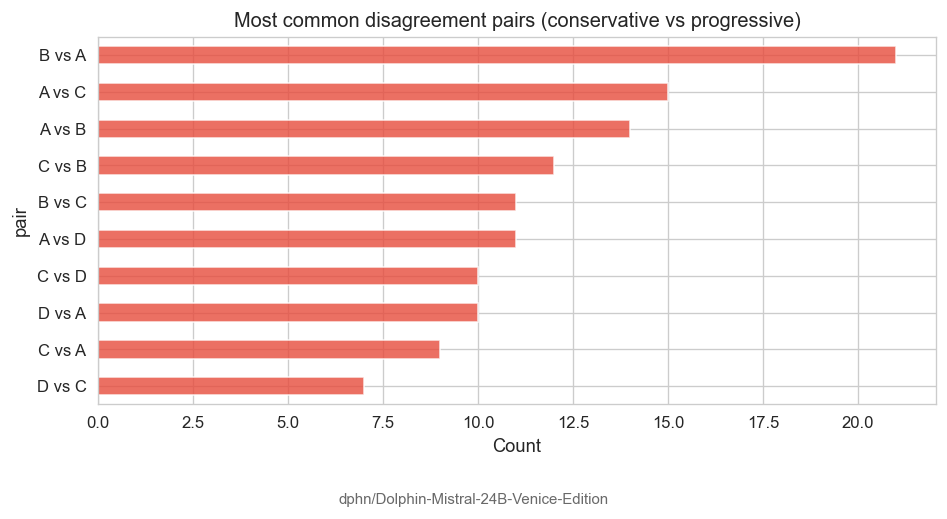

In [7]:
# ── Disagreement details: which answer pairs occur? ────────────────────
disagree = paired_df[paired_df["is_disagreement"]].copy()
disagree["pair"] = disagree[f"answer_{P1}"] + " vs " + disagree[f"answer_{P2}"]

pair_counts = disagree["pair"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
pair_counts.plot.barh(ax=ax, color="#e74c3c", alpha=0.8)
ax.set_xlabel("Count")
ax.set_title(f"Most common disagreement pairs ({P1.replace('persona_','')} vs {P2.replace('persona_','')})")
ax.invert_yaxis()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

## 3. Logit Lens Analysis

**How it works:** At each layer, we take the hidden state vector, run it through the model's final LayerNorm and language model head (the same components used at the very end), and look at the resulting logits for A, B, C, D. This tells us: "If the model stopped computing right here, what answer would it give?"

**Why this matters for our experiment:** We want to know *when* the conservative and progressive personas start giving different answers. If they diverge early (say layer 5 out of 40), that suggests persona effects penetrate deep into the model's computation. If they only diverge at the very last few layers, the persona might just be a shallow output filter that flips the answer at the end.

In [8]:
# Convert raw logits to probabilities (softmax over ABCD at each layer)
ll_probs = {}  # persona -> [n_q, n_layers, 4] float probabilities
for p in PERSONAS:
    ll_probs[p] = F.softmax(logit_lens[p].float(), dim=-1)  # [n_q, n_layers, 4]

# Get chosen answer index per persona per question
choice_to_idx = {c: i for i, c in enumerate(CHOICES)}
chosen_idx = {}  # persona -> [n_q] int tensor
for p in PERSONAS:
    sub = logits_df[logits_df["persona"] == p].sort_values("question_id")
    chosen_idx[p] = torch.tensor([choice_to_idx[a] for a in sub["chosen_answer"].values])

# Precompute agreement/disagreement masks
agree_qids = set(paired_df[paired_df["is_agreement"]]["question_id"])
disagree_qids = set(paired_df[paired_df["is_disagreement"]]["question_id"])
agree_mask = torch.tensor([qid in agree_qids for qid in QUESTION_IDS])
disagree_mask = torch.tensor([qid in disagree_qids for qid in QUESTION_IDS])

layers = np.arange(N_LAYERS)
print("Logit lens probabilities and masks computed.")
print(f"Agreement questions: {agree_mask.sum()}, Disagreement: {disagree_mask.sum()}")

Logit lens probabilities and masks computed.
Agreement questions: 75, Disagreement: 130


### How confident is the model in its final answer at each layer?

For each question, we know what answer the model ultimately chose at the final layer (e.g., "B"). This plot tracks: across all 205 questions, how much probability does the logit lens assign to that final answer at each intermediate layer?

- **Near 0.25 (chance)** in early layers = the model hasn't "decided" yet
- **Rising toward 1.0** in later layers = the model is committing to its answer
- The **shaded region** shows +/- 1 standard deviation across questions

**What to look for:** How quickly does each persona's answer "crystallize"? If one persona commits earlier, it may be forming a stronger internal representation.

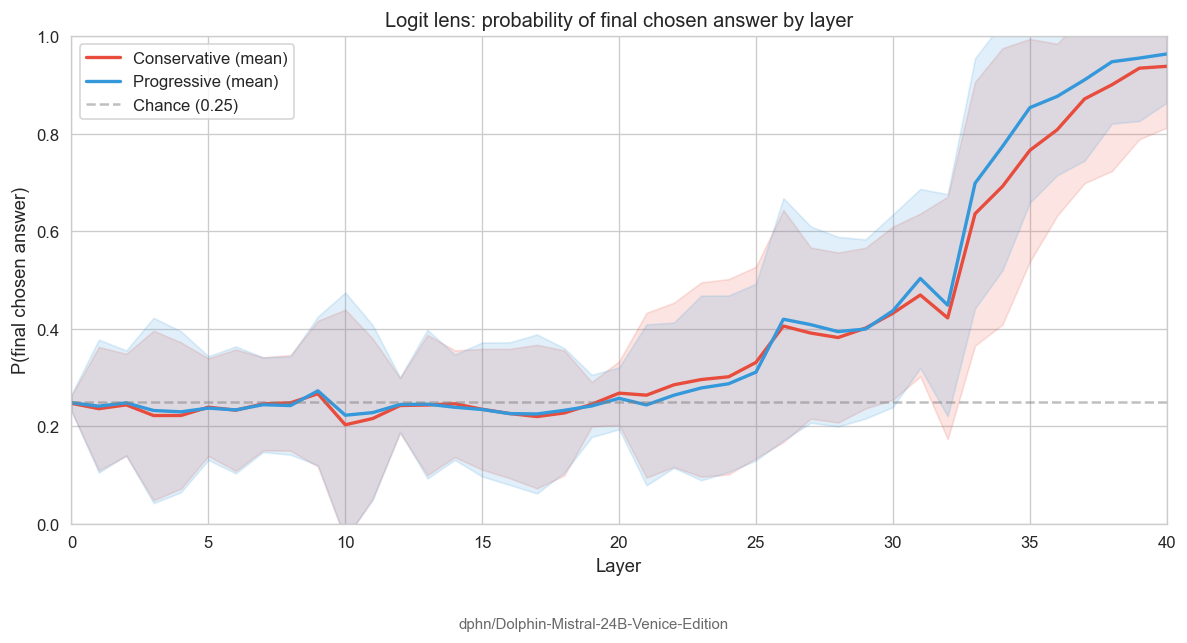

In [9]:
# ── Mean probability of final chosen answer at each layer ──────────────
fig, ax = plt.subplots(figsize=(10, 5))

for p, color in zip(PERSONAS, ["#e74c3c", "#3498db"]):
    probs = ll_probs[p]  # [n_q, n_layers, 4]
    idx = chosen_idx[p]  # [n_q]
    # Gather: for each question, at each layer, get P(final answer)
    chosen_prob = probs[
        torch.arange(N_QUESTIONS).unsqueeze(1),
        torch.arange(N_LAYERS).unsqueeze(0),
        idx.unsqueeze(1).expand(-1, N_LAYERS)
    ]  # [n_q, n_layers]
    mean_prob = chosen_prob.mean(dim=0).numpy()
    std_prob = chosen_prob.std(dim=0).numpy()
    label = p.replace("persona_", "").title()
    ax.plot(layers, mean_prob, color=color, linewidth=2, label=f"{label} (mean)")
    ax.fill_between(layers, mean_prob - std_prob, mean_prob + std_prob,
                    color=color, alpha=0.15)

ax.axhline(0.25, color="gray", linestyle="--", alpha=0.5, label="Chance (0.25)")
ax.set_xlabel("Layer")
ax.set_ylabel("P(final chosen answer)")
ax.set_title("Logit lens: probability of final chosen answer by layer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
ax.set_ylim(0, 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### What fraction of questions have the "right" answer at each layer?

Similar to above, but binary: at each layer, does the argmax (top-1 prediction) match the final answer? This is a stricter measure — the probability might be rising but the argmax might still be a different letter until the probability crosses 50%.

**What to look for:** The layer at which this curve rises above chance (0.25) tells us when the model starts "getting it right" internally, even if it isn't fully confident yet.

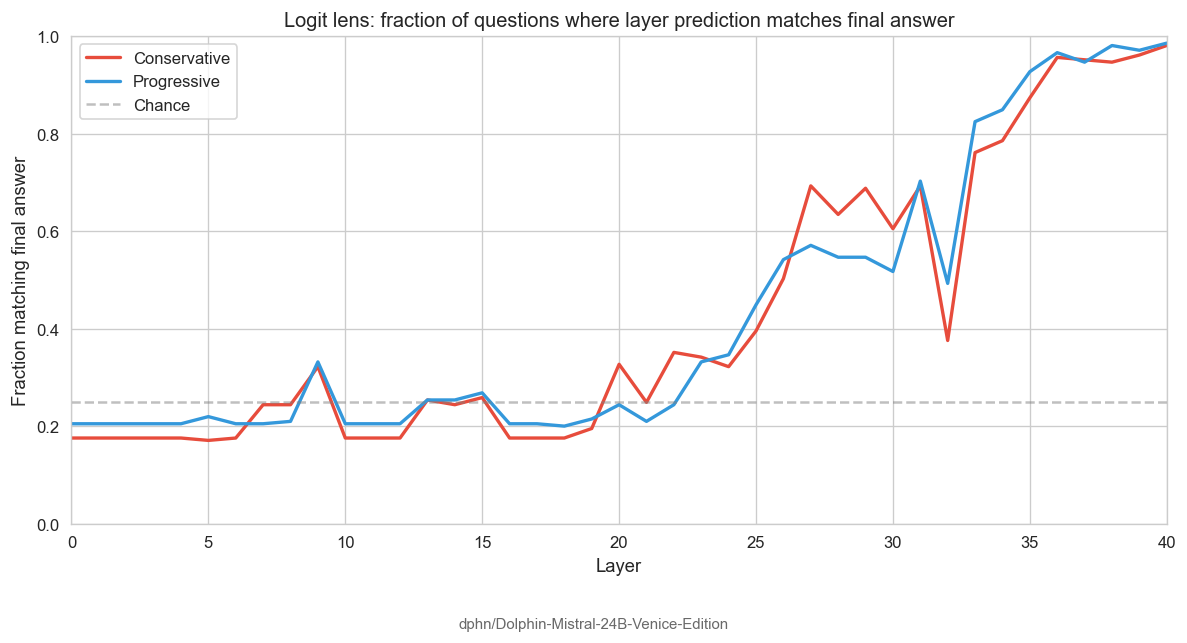

In [10]:
# ── Fraction of questions where layer argmax matches final answer ──────
fig, ax = plt.subplots(figsize=(10, 5))

for p, color in zip(PERSONAS, ["#e74c3c", "#3498db"]):
    probs = ll_probs[p]  # [n_q, n_layers, 4]
    layer_argmax = probs.argmax(dim=-1)  # [n_q, n_layers]
    final_answer = chosen_idx[p].unsqueeze(1).expand_as(layer_argmax)
    match_rate = (layer_argmax == final_answer).float().mean(dim=0).numpy()
    label = p.replace("persona_", "").title()
    ax.plot(layers, match_rate, color=color, linewidth=2, label=label)

ax.axhline(0.25, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Layer")
ax.set_ylabel("Fraction matching final answer")
ax.set_title("Logit lens: fraction of questions where layer prediction matches final answer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
ax.set_ylim(0, 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### KL divergence: how different are the two personas' predictions at each layer?

**KL divergence** (Kullback-Leibler divergence) measures how different two probability distributions are. Here, at each layer, both personas produce a probability distribution over [A, B, C, D]. We compute how different those two distributions are.

- **KL = 0** means the personas have *identical* predictions at that layer (same probabilities for A, B, C, D)
- **KL > 0** means they differ — higher = more different
- We use **symmetric KL** (average of KL(P1||P2) and KL(P2||P1)) so the measure is fair to both directions

**What to look for:**
- **Green line (agreement questions):** These questions have the same final answer, so KL should stay low throughout
- **Red line (disagreement questions):** These have different final answers — KL should rise at some point, and *where* it rises tells us when the persona-driven divergence begins
- If KL rises only in the last few layers, the persona effect is shallow. If it rises early or in the middle, the effect goes deeper.

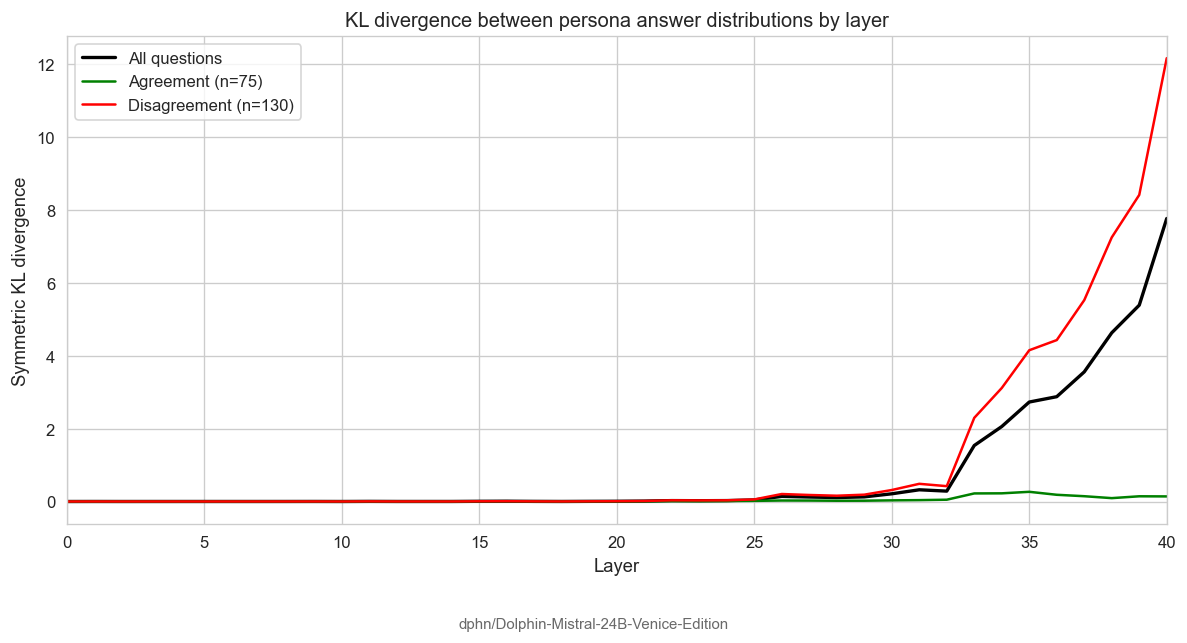

In [11]:
# ── KL divergence between personas at each layer ──────────────────────
eps = 1e-8
p1_probs = ll_probs[P1].clamp(min=eps)  # [n_q, n_layers, 4]
p2_probs = ll_probs[P2].clamp(min=eps)

kl_p1_p2 = (p1_probs * (p1_probs.log() - p2_probs.log())).sum(dim=-1)  # [n_q, n_layers]
kl_p2_p1 = (p2_probs * (p2_probs.log() - p1_probs.log())).sum(dim=-1)
# Symmetric KL = (KL(P||Q) + KL(Q||P)) / 2
sym_kl = ((kl_p1_p2 + kl_p2_p1) / 2)  # [n_q, n_layers]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(layers, sym_kl.mean(dim=0).numpy(), "k-", linewidth=2, label="All questions")
if agree_mask.sum() > 0:
    ax.plot(layers, sym_kl[agree_mask].mean(dim=0).numpy(), "g-", linewidth=1.5,
            label=f"Agreement (n={agree_mask.sum()})")
if disagree_mask.sum() > 0:
    ax.plot(layers, sym_kl[disagree_mask].mean(dim=0).numpy(), "r-", linewidth=1.5,
            label=f"Disagreement (n={disagree_mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("Symmetric KL divergence")
ax.set_title("KL divergence between persona answer distributions by layer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### KL divergence broken down by question category

Same metric as above, but one line per question category. This tells us whether certain types of questions (e.g., policy vs ethical dilemmas) produce earlier or stronger divergence between personas.

**What to look for:** Factual (control) questions should have near-zero KL at all layers. Policy and Values questions should show the highest KL, especially in later layers.

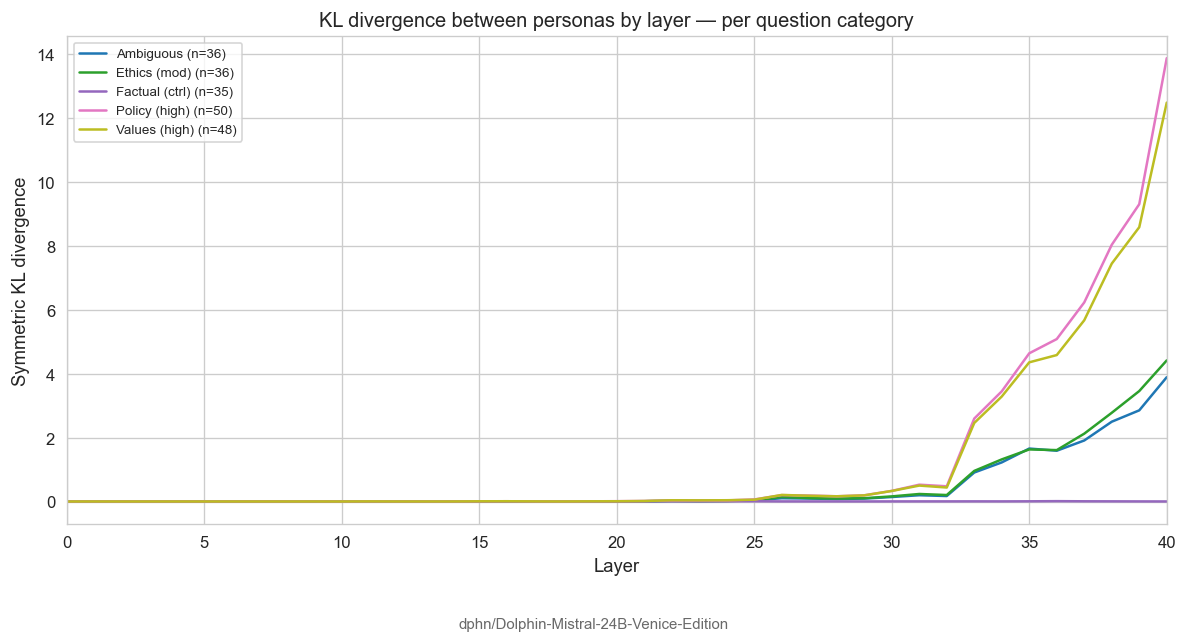

In [12]:
# ── KL divergence by question category ────────────────────────────────
cat_masks = {}
for cat_short in cat_summary["cat_short"]:
    qids = set(paired_df[paired_df["cat_short"] == cat_short]["question_id"])
    cat_masks[cat_short] = torch.tensor([qid in qids for qid in QUESTION_IDS])

fig, ax = plt.subplots(figsize=(10, 5))
colors_cat = plt.cm.tab10(np.linspace(0, 0.8, len(cat_masks)))
for (cat_short, mask), color in zip(cat_masks.items(), colors_cat):
    if mask.sum() > 0:
        ax.plot(layers, sym_kl[mask].mean(dim=0).numpy(), linewidth=1.5,
                color=color, label=f"{cat_short} (n={mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("Symmetric KL divergence")
ax.set_title("KL divergence between personas by layer \u2014 per question category")
ax.legend(fontsize=8)
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Heatmap: which answer does the logit lens predict at each layer?

Each row is one disagreement question. Each column is a layer (0 to 40). The color shows which answer letter (A/B/C/D) the logit lens predicts at that layer. Left panel = conservative, right panel = progressive.

**What to look for:** In early layers, both panels should look similar (before the persona takes effect). At some point, the colors should diverge between the two panels — the conservative and progressive start "thinking" different answers. The layer where colors start differing between panels is the divergence point for that question.

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_26434/4175845884.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


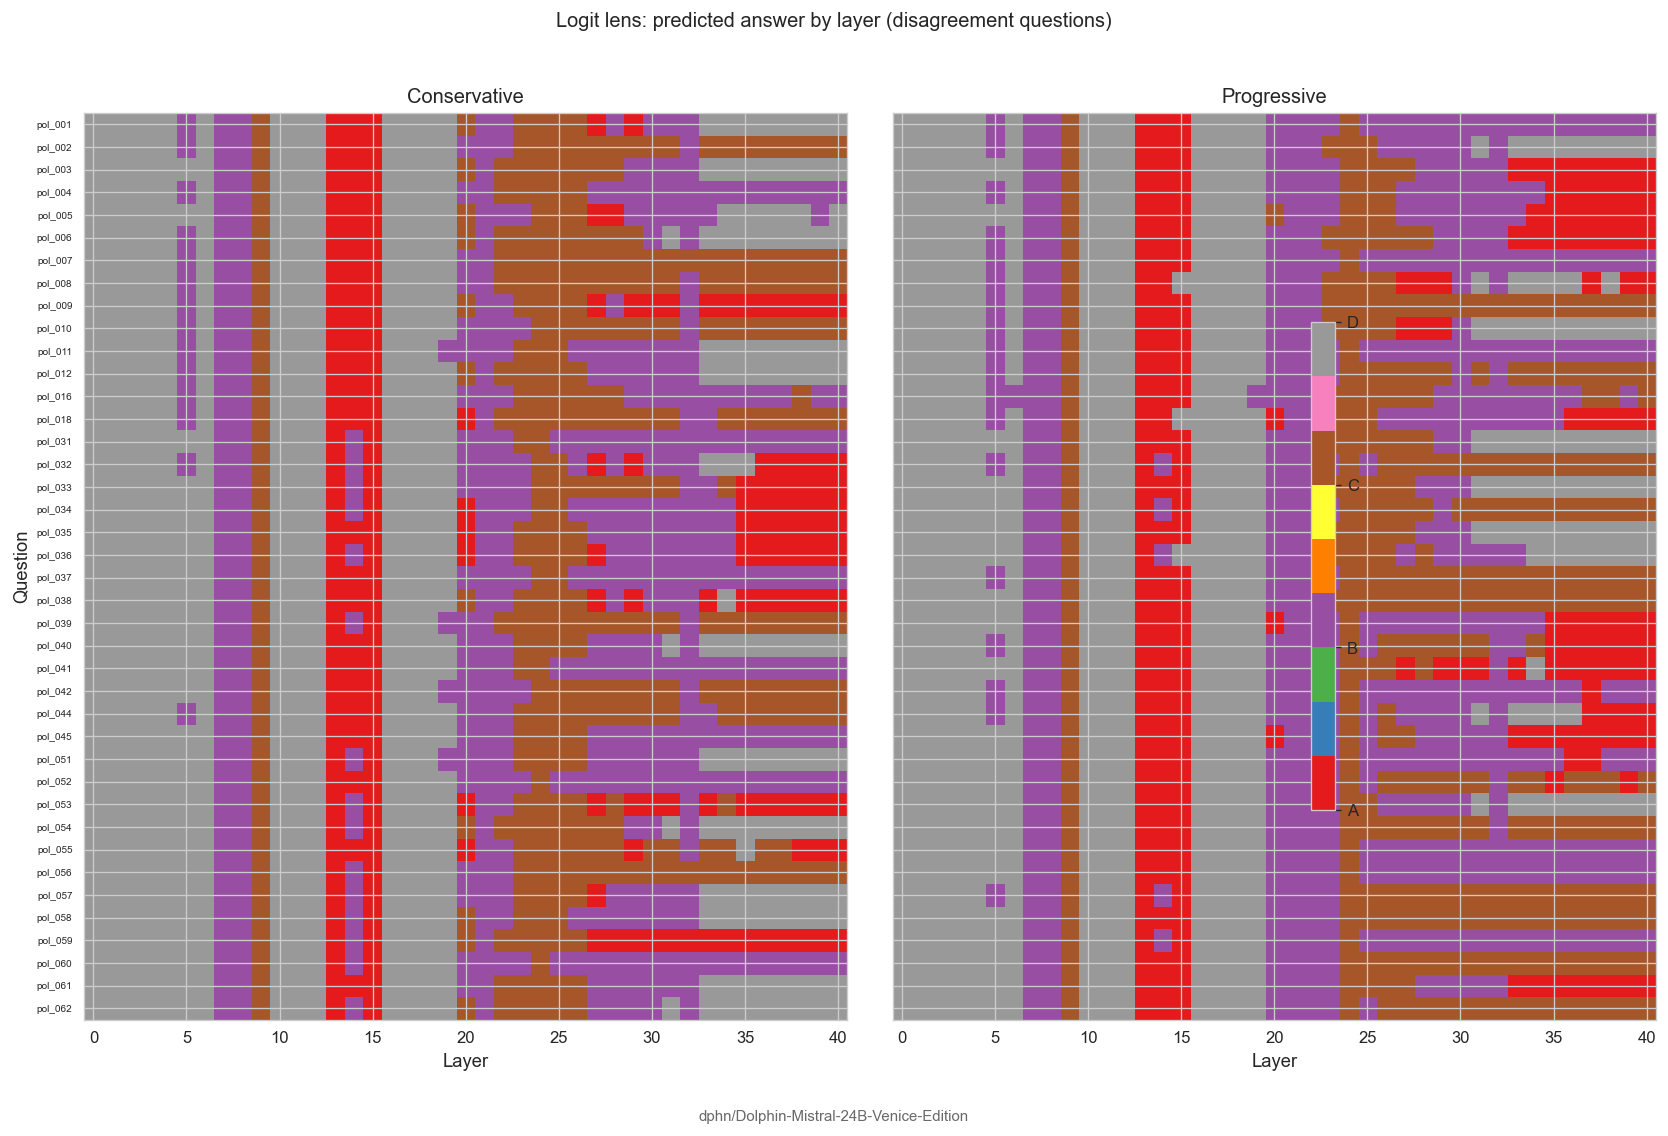

In [13]:
# ── Logit lens heatmap: answer letter at each layer for disagreement Qs ─
disagree_indices = [i for i, qid in enumerate(QUESTION_IDS) if qid in disagree_qids]
show_indices = disagree_indices[:40]  # show up to 40

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(show_indices) * 0.22)), sharey=True)

for ax, p in zip(axes, PERSONAS):
    probs = ll_probs[p]  # [n_q, n_layers, 4]
    argmax_idx = probs[show_indices].argmax(dim=-1).numpy()  # [n_show, n_layers]
    im = ax.imshow(argmax_idx, aspect="auto", cmap="Set1", vmin=0, vmax=3,
                   interpolation="nearest")
    ax.set_xlabel("Layer")
    if ax == axes[0]:
        ax.set_ylabel("Question")
        ax.set_yticks(range(len(show_indices)))
        ax.set_yticklabels([QUESTION_IDS[i] for i in show_indices], fontsize=6)
    ax.set_title(p.replace("persona_", "").title())

cbar = fig.colorbar(im, ax=axes, ticks=[0, 1, 2, 3], shrink=0.6)
cbar.set_ticklabels(CHOICES)
fig.suptitle("Logit lens: predicted answer by layer (disagreement questions)", y=1.02)
_model_footer(fig, MODEL_NAME, y=-0.02)
plt.tight_layout()
plt.show()

### Divergence onset: when do personas start consistently disagreeing?

For each disagreement question, we find the **first layer** where the two personas' logit-lens argmax predictions differ and *remain different for at least 4 of the next 5 layers* (or stay different through the end if fewer than 5 layers remain). This windowed definition is more robust than requiring strict disagreement all the way to the final layer, which can be thrown off by a single late flip.

- **Earlier onset** → the model starts "thinking differently" for the two personas early in the network.
- **Later onset** → the personas share computation for most of the forward pass, diverging only near the output.
- The histogram shows the distribution across all disagreement questions.

In [ ]:
# ── Divergence onset: first layer where personas consistently disagree ─
WINDOW = 5       # look-ahead window
THRESHOLD = 4    # must disagree in at least this many of the next WINDOW layers

divergence_layers = []
for qi in disagree_indices:
    argmax_p1 = ll_probs[P1][qi].argmax(dim=-1)  # [n_layers]
    argmax_p2 = ll_probs[P2][qi].argmax(dim=-1)
    differs = (argmax_p1 != argmax_p2).numpy()
    onset = N_LAYERS - 1
    for l in range(N_LAYERS):
        remaining = N_LAYERS - l
        window = min(WINDOW, remaining)
        thresh = min(THRESHOLD, window)  # relax near the end
        if differs[l:l + window].sum() >= thresh:
            onset = l
            break
    divergence_layers.append(onset)

divergence_layers = np.array(divergence_layers)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(divergence_layers, bins=np.arange(0, N_LAYERS + 1) - 0.5,
        color="#e74c3c", alpha=0.8, edgecolor="white")
ax.axvline(divergence_layers.mean(), color="black", linestyle="--", linewidth=2,
           label=f"Mean onset: layer {divergence_layers.mean():.1f}")
ax.axvline(np.median(divergence_layers), color="blue", linestyle=":", linewidth=2,
           label=f"Median onset: layer {np.median(divergence_layers):.0f}")
ax.set_xlabel("Layer of divergence onset")
ax.set_ylabel("Count of questions")
ax.set_title(f"Divergence onset (≥{THRESHOLD}/{WINDOW} layers disagree in look-ahead window)")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print(f"Divergence onset — mean: {divergence_layers.mean():.1f}, "
      f"median: {np.median(divergence_layers):.0f}, "
      f"std: {divergence_layers.std():.1f}")

## 4. Activation Analysis

### What are we comparing?

The logit lens (above) looked at the model's *predictions* at each layer. Here we look at the raw **hidden state vectors** themselves — the 5,120-dimensional vectors that the model computes at each layer.

For the same question, the conservative and progressive personas produce different hidden states (because their system prompts differ). We want to know: **how different are these hidden state vectors?**

- **Cosine similarity** measures directional similarity (1.0 = pointing the same way, 0.0 = orthogonal). This ignores magnitude and focuses on the "direction" of the representation.
- **L2 distance** measures the raw Euclidean distance. This captures both direction and magnitude differences.
- **PCA** projects the high-dimensional vectors into 2D so we can visualize clustering.

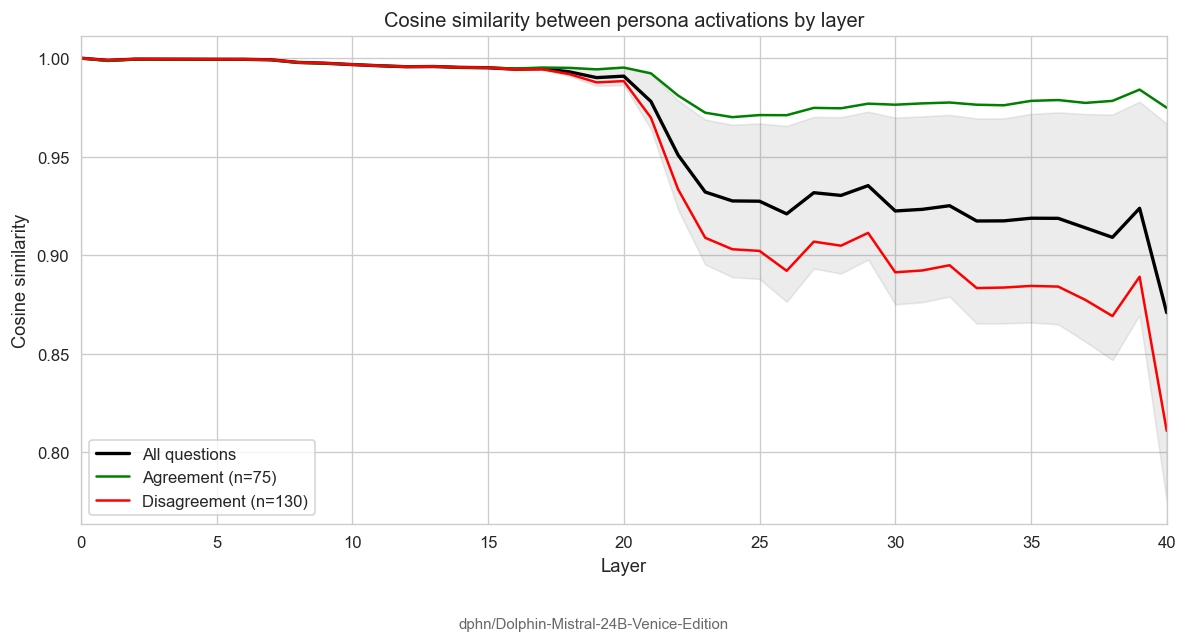

In [15]:
# ── Cosine similarity between persona activations per layer ────────────
act_p1 = activations[P1].float()  # [n_q, n_layers, d_model]
act_p2 = activations[P2].float()

act_p1_norm = F.normalize(act_p1, dim=-1)
act_p2_norm = F.normalize(act_p2, dim=-1)
cos_sim = (act_p1_norm * act_p2_norm).sum(dim=-1)  # [n_q, n_layers]

fig, ax = plt.subplots(figsize=(10, 5))
mean_cos = cos_sim.mean(dim=0).numpy()
std_cos = cos_sim.std(dim=0).numpy()

ax.plot(layers, mean_cos, "k-", linewidth=2, label="All questions")
ax.fill_between(layers, mean_cos - std_cos, mean_cos + std_cos, alpha=0.15, color="gray")
if agree_mask.sum() > 0:
    ax.plot(layers, cos_sim[agree_mask].mean(dim=0).numpy(), "g-", linewidth=1.5,
            label=f"Agreement (n={agree_mask.sum()})")
if disagree_mask.sum() > 0:
    ax.plot(layers, cos_sim[disagree_mask].mean(dim=0).numpy(), "r-", linewidth=1.5,
            label=f"Disagreement (n={disagree_mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity between persona activations by layer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Cosine similarity between personas by layer

For the same question, how similar is the conservative's hidden state to the progressive's hidden state at each layer? A cosine similarity of 1.0 means the vectors point in exactly the same direction; lower values mean the personas' internal representations are diverging.

**What to look for:**
- **Green (agreement)** should stay high — when they pick the same answer, their internal states should be similar
- **Red (disagreement)** should drop — the personas are "thinking differently" about these questions
- **Where the drop happens** tells us at which layers the persona starts influencing the representation
- The gap between green and red lines shows how much the activations separate for questions where persona actually matters

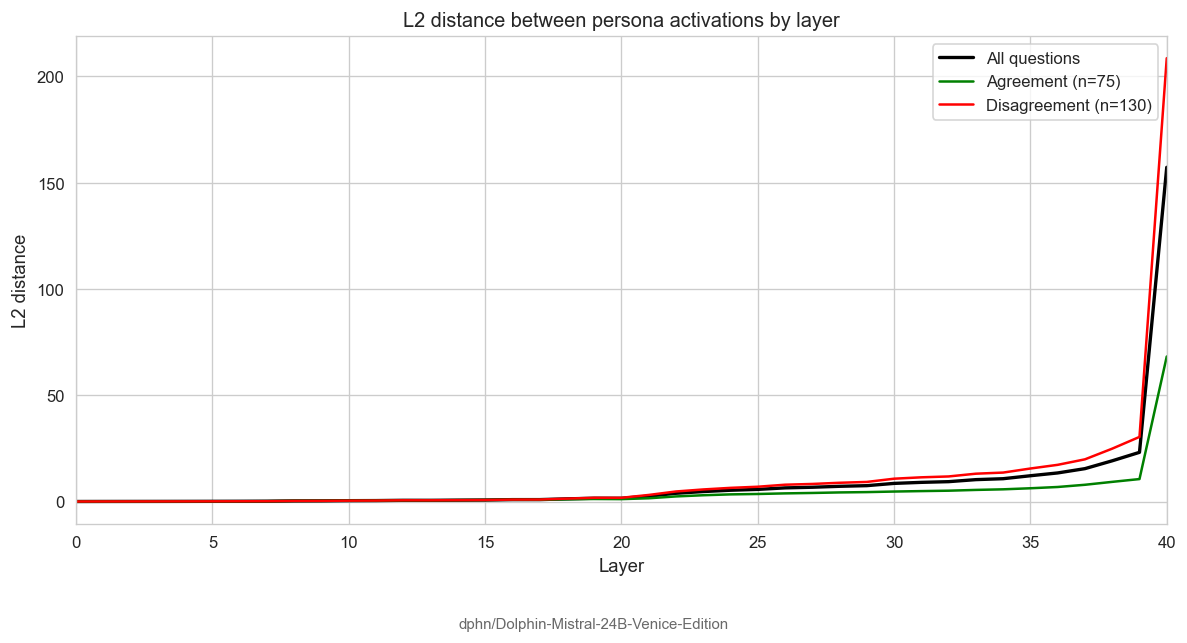

In [16]:
# ── L2 distance between persona activations per layer ─────────────────
l2_dist = (act_p1 - act_p2).norm(dim=-1)  # [n_q, n_layers]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(layers, l2_dist.mean(dim=0).numpy(), "k-", linewidth=2, label="All questions")
if agree_mask.sum() > 0:
    ax.plot(layers, l2_dist[agree_mask].mean(dim=0).numpy(), "g-", linewidth=1.5,
            label=f"Agreement (n={agree_mask.sum()})")
if disagree_mask.sum() > 0:
    ax.plot(layers, l2_dist[disagree_mask].mean(dim=0).numpy(), "r-", linewidth=1.5,
            label=f"Disagreement (n={disagree_mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("L2 distance")
ax.set_title("L2 distance between persona activations by layer")
ax.legend()
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### L2 distance between personas by layer

Same idea as cosine similarity, but measured as Euclidean distance (||h_conservative - h_progressive||). Higher = more different. This captures magnitude differences that cosine similarity ignores.

**What to look for:** Same pattern — disagreement questions (red) should show larger distances, especially in later layers. The *shape* of the curve tells us whether the divergence is gradual or sudden.

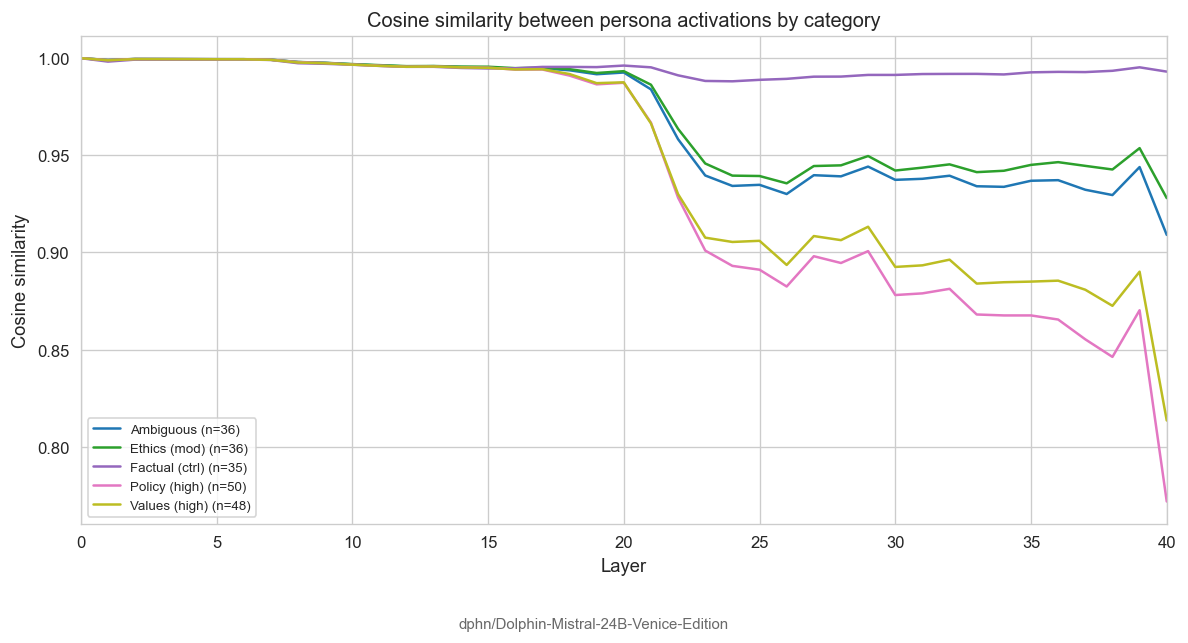

In [17]:
# ── Cosine similarity by question category ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for (cat_short, mask), color in zip(cat_masks.items(), colors_cat):
    if mask.sum() > 0:
        ax.plot(layers, cos_sim[mask].mean(dim=0).numpy(), linewidth=1.5,
                color=color, label=f"{cat_short} (n={mask.sum()})")

ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity between persona activations by category")
ax.legend(fontsize=8)
ax.set_xlim(0, N_LAYERS - 1)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### PCA: visualizing persona separation in 2D

**PCA** (Principal Component Analysis) compresses the 5,120-dimensional hidden states into 2 dimensions so we can plot them. We stack all 205 conservative + 205 progressive hidden states at a given layer and project them to 2D.

**What to look for:** At early layers, conservative (red) and progressive (blue) dots should overlap — the model hasn't differentiated them yet. At later layers, the clusters may separate, meaning the model's internal representations are measurably different between personas. The percentage labels on the axes show how much variance each principal component explains.

/Users/daylight/miniconda3/envs/spar/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


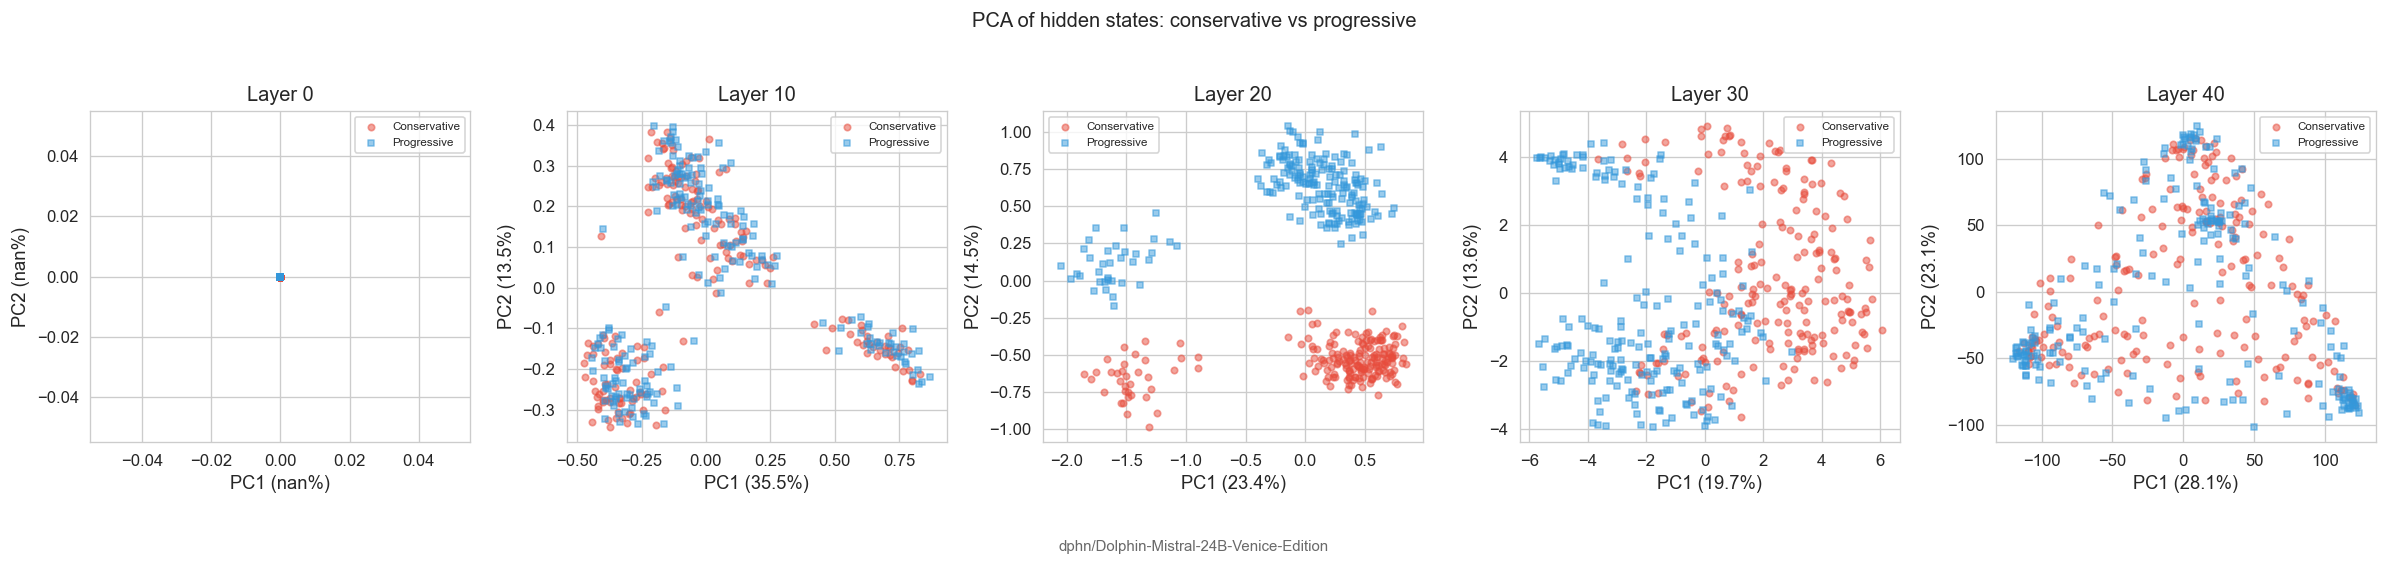

In [18]:
# ── PCA: project activations from selected layers into 2D ─────────────
from sklearn.decomposition import PCA

layer_picks = [0, N_LAYERS // 4, N_LAYERS // 2, 3 * N_LAYERS // 4, N_LAYERS - 1]
layer_picks = sorted(set(layer_picks))

fig, axes = plt.subplots(1, len(layer_picks), figsize=(4 * len(layer_picks), 4))
if len(layer_picks) == 1:
    axes = [axes]

for ax, layer in zip(axes, layer_picks):
    x1 = act_p1[:, layer, :].numpy()  # [n_q, d_model]
    x2 = act_p2[:, layer, :].numpy()
    X = np.concatenate([x1, x2], axis=0)  # [2*n_q, d_model]
    labels = ([P1.replace('persona_', '')] * N_QUESTIONS +
              [P2.replace('persona_', '')] * N_QUESTIONS)

    pca = PCA(n_components=2)
    Z = pca.fit_transform(X)

    for p_label, color, marker in [
        (P1.replace('persona_', ''), "#e74c3c", "o"),
        (P2.replace('persona_', ''), "#3498db", "s")
    ]:
        mask_p = np.array(labels) == p_label
        ax.scatter(Z[mask_p, 0], Z[mask_p, 1], c=color, marker=marker,
                   alpha=0.5, s=15, label=p_label.title())

    var_exp = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
    ax.set_title(f"Layer {layer}")
    ax.legend(fontsize=7)

fig.suptitle("PCA of hidden states: conservative vs progressive", y=1.04)
_model_footer(fig, MODEL_NAME, y=-0.06)
plt.tight_layout()
plt.show()

### PCA at final layer: do agreement vs disagreement questions cluster?

Within a single persona's final-layer activations, are the "agreement" questions (where both personas gave the same answer) in a different region of representation space than the "disagreement" questions?

If they cluster separately, it would suggest the model "knows" internally when it's about to give a politically charged answer.

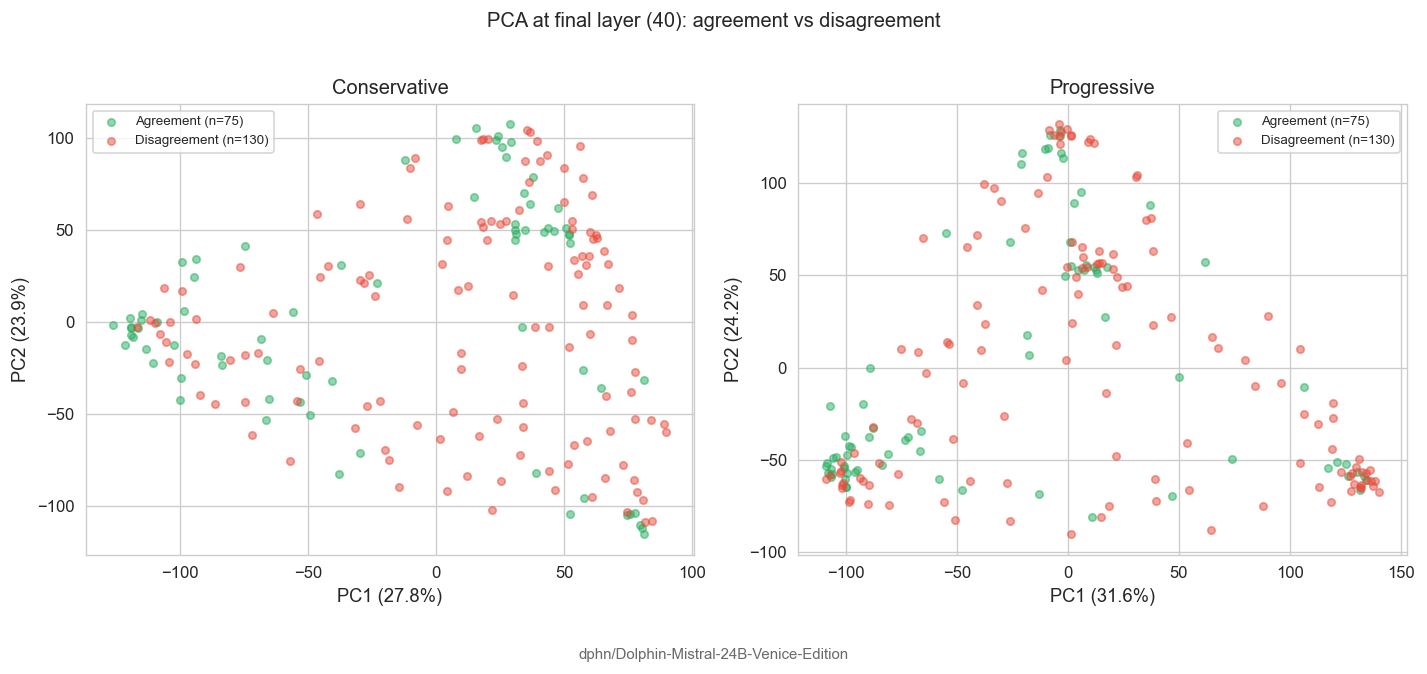

In [19]:
# ── PCA at final layer, colored by agreement/disagreement ─────────────
final_layer = N_LAYERS - 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

agree_np = agree_mask.numpy()
disagree_np = disagree_mask.numpy()

for ax, p in zip(axes, PERSONAS):
    X = activations[p][:, final_layer, :].float().numpy()
    pca = PCA(n_components=2)
    Z = pca.fit_transform(X)

    ax.scatter(Z[agree_np, 0], Z[agree_np, 1], c="#27ae60", alpha=0.5,
               s=20, label=f"Agreement (n={agree_np.sum()})")
    ax.scatter(Z[disagree_np, 0], Z[disagree_np, 1], c="#e74c3c", alpha=0.5,
               s=20, label=f"Disagreement (n={disagree_np.sum()})")

    var_exp = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
    ax.set_title(p.replace("persona_", "").title())
    ax.legend(fontsize=8)

fig.suptitle(f"PCA at final layer ({final_layer}): agreement vs disagreement", y=1.02)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Activation difference by question category

The magnitude of the vector difference between the conservative's and progressive's hidden states at the final layer, grouped by question category. Larger differences mean the personas' internal states are more distinct for that category.

**What to look for:** Policy and Values categories (where we expect disagreement) should show larger differences than Factual (control) questions.

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_26434/2086115835.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diff_df, x="cat_short", y="diff_norm", ax=ax, palette="Set2")


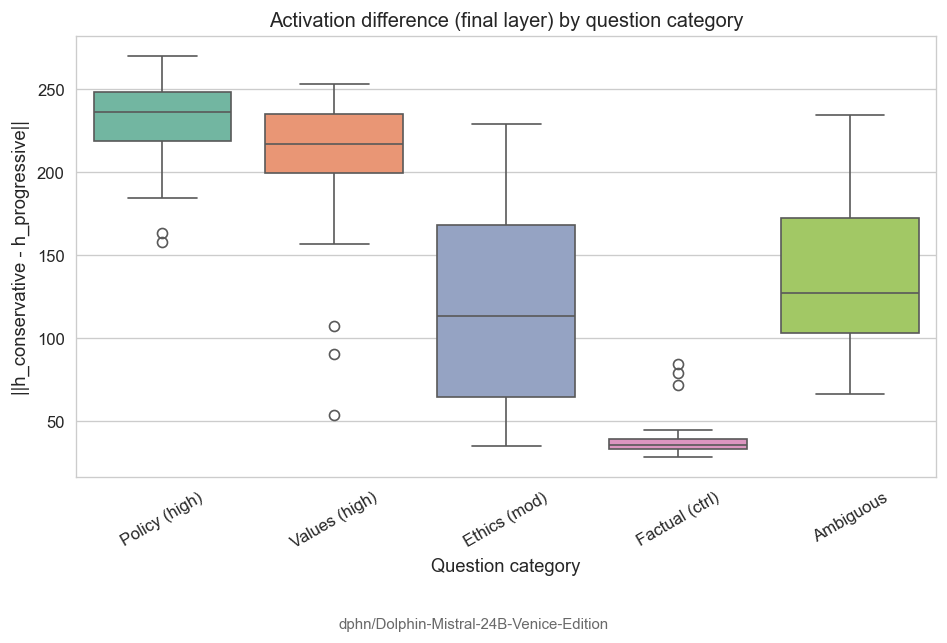

In [20]:
# ── Activation difference magnitude by category ───────────────────────
diff_norms = (act_p1[:, -1, :] - act_p2[:, -1, :]).norm(dim=-1).numpy()  # [n_q]

diff_df = pd.DataFrame({
    "question_id": QUESTION_IDS,
    "diff_norm": diff_norms,
})
diff_df = diff_df.merge(
    paired_df[["question_id", "cat_short", "is_disagreement"]],
    on="question_id"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=diff_df, x="cat_short", y="diff_norm", ax=ax, palette="Set2")
ax.set_xlabel("Question category")
ax.set_ylabel("||h_conservative - h_progressive||")
ax.set_title("Activation difference (final layer) by question category")
ax.tick_params(axis="x", rotation=30)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

## 5. Linear Probes

### What are linear probes?

A **linear probe** is a simple logistic regression classifier trained on the model's hidden-state vectors. It answers: "given just the activations at layer L, can a linear classifier predict which answer (A/B/C/D) the model chose?"

We train probes using the separate script `scripts/train_probes.py`, which saves results to `<run_dir>/probes/`. This notebook **loads** those pre-computed results rather than retraining, ensuring a single source of truth.

**Two key probe types:**
- **Same-persona:** Train on Persona A's activations, predict Persona A's answers. High accuracy = the answer is linearly decodable.
- **Cross-persona:** Train on Persona A's activations, then evaluate on Persona B's activations while still scoring against Persona A's labels. High accuracy would mean both personas encode the same answer information. Low accuracy (especially on disagreement questions) means the personas encode genuinely different answers.

Run probes first: `python scripts/train_probes.py <run_dir>`

In [ ]:
# ── Load pre-computed probes OR train inline ─────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tqdm.auto import tqdm

probes_dir = RUN_DIR / "probes"
metrics_path = probes_dir / "probe_metrics.csv"

if metrics_path.exists():
    # ── LOAD from train_probes.py output ──────────────────────────────
    probe_metrics = pd.read_csv(metrics_path)
    print(f"Loaded {len(probe_metrics)} probe metric rows from {metrics_path}")

    predictions_path = probes_dir / "probe_predictions.csv"
    if predictions_path.exists():
        probe_predictions = pd.read_csv(predictions_path)
        print(f"Loaded {len(probe_predictions)} prediction rows")
    else:
        probe_predictions = None

    manifest_path = probes_dir / "split_manifest.json"
    if manifest_path.exists():
        with open(manifest_path) as f:
            split_manifest = json.load(f)
        print(f"Split: train={split_manifest['n_train']}, "
              f"val={split_manifest['n_val']}, test={split_manifest['n_test']}")
else:
    # ── TRAIN inline (no pre-computed probes found) ───────────────────
    print(f"No probes found at {probes_dir}, training inline...")

    answers = {}
    for p in PERSONAS:
        sub = logits_df[logits_df["persona"] == p].sort_values("question_id")
        answers[p] = sub.set_index("question_id").loc[QUESTION_IDS, "chosen_answer"].values

    le = LabelEncoder()
    le.fit(np.concatenate([answers[p] for p in PERSONAS]))
    labels = {p: le.transform(answers[p]) for p in PERSONAS}

    # 60/20/20 split (matches train_probes.py logic)
    rng = np.random.RandomState(42)
    indices = np.arange(N_QUESTIONS)
    rng.shuffle(indices)
    n_test = max(1, int(0.2 * N_QUESTIONS))
    n_val = max(1, int(0.2 * N_QUESTIONS))
    train_idx = indices[:N_QUESTIONS - n_val - n_test]
    val_idx = indices[N_QUESTIONS - n_val - n_test:N_QUESTIONS - n_test]
    test_idx = indices[N_QUESTIONS - n_test:]

    test_agree = agree_mask.numpy()[test_idx]
    test_disagree = disagree_mask.numpy()[test_idx]

    print(f"Split: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")
    print(f"Test set: {test_agree.sum()} agreement, {test_disagree.sum()} disagreement")

    eval_combos = []
    for probe_p in PERSONAS:
        other_p = [p for p in PERSONAS if p != probe_p][0]
        eval_combos.append((probe_p, probe_p, "same_persona"))
        eval_combos.append((probe_p, other_p, "cross_persona"))

    C_VALUES = [0.01, 0.1, 1.0, 10.0]
    metric_rows = []

    for layer in tqdm(range(N_LAYERS), desc="Training probes"):
        probes_dict = {}
        scalers_dict = {}

        for pname in PERSONAS:
            X_all = activations[pname][:, layer, :].float().numpy()
            y_all = labels[pname]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_all[train_idx])
            X_val = scaler.transform(X_all[val_idx])
            y_train, y_val = y_all[train_idx], y_all[val_idx]

            best_score, best_clf = -1.0, None
            for C in C_VALUES:
                clf = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", random_state=42)
                clf.fit(X_train, y_train)
                score = clf.score(X_val, y_val)
                if score > best_score:
                    best_score = score
                    best_clf = clf

            probes_dict[pname] = best_clf
            scalers_dict[pname] = scaler

        for probe_p, act_p, combo_type in eval_combos:
            probe = probes_dict[probe_p]
            scaler = scalers_dict[probe_p]
            X_test = scaler.transform(activations[act_p][:, layer, :].float().numpy()[test_idx])
            y_test = labels[probe_p][test_idx]

            for subset_name, subset_mask in [("full", None), ("agreement", test_agree),
                                              ("disagreement", test_disagree)]:
                if subset_mask is not None:
                    if subset_mask.sum() == 0:
                        continue
                    acc = float(probe.score(X_test[subset_mask], y_test[subset_mask]))
                    n_s = int(subset_mask.sum())
                else:
                    acc = float(probe.score(X_test, y_test))
                    n_s = len(y_test)
                metric_rows.append({
                    "layer": layer, "probe_persona": probe_p,
                    "activation_persona": act_p, "combo_type": combo_type,
                    "subset": subset_name, "accuracy": acc, "n_samples": n_s,
                })

    probe_metrics = pd.DataFrame(metric_rows)
    print(f"Trained probes at all {N_LAYERS} layers. {len(probe_metrics)} metric rows.")

# Quick summary
for combo in probe_metrics["combo_type"].unique():
    sub = probe_metrics[(probe_metrics["combo_type"] == combo) &
                        (probe_metrics["subset"] == "full")]
    final = sub[sub["layer"] == sub["layer"].max()]
    mean_acc = final["accuracy"].mean()
    print(f"  {combo:15s} final-layer accuracy (full): {mean_acc:.3f}")

### Probe accuracy by layer

**Left panel (full):** Accuracy on all test questions. Solid lines = same-persona (baseline), dashed = cross-persona.

**Right panel (disagreement):** Accuracy only on questions where the personas gave different final answers. This is the most informative subset — on agreement questions, cross-persona probes trivially work since both personas chose the same answer.

**What to look for:**
- Same-persona accuracy should rise from chance (0.25) to near 1.0 in later layers
- The key question is the **gap** between solid and dashed lines in the disagreement panel. A large gap = deep persona effects. A small gap = shallow.

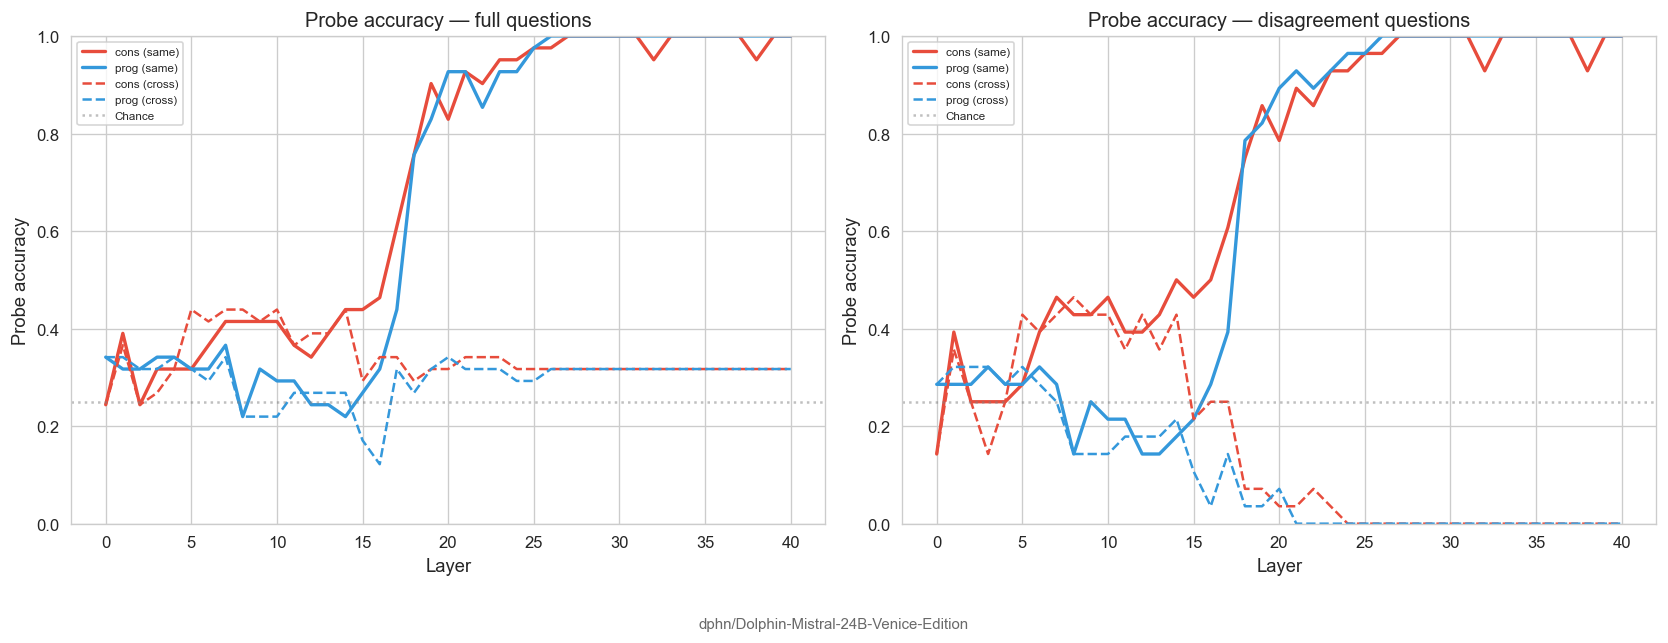

In [22]:
# ── Same-persona vs cross-persona probe accuracy by layer ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset in zip(axes, ["full", "disagreement"]):
    sub = probe_metrics[probe_metrics["subset"] == subset]
    if sub.empty:
        ax.text(0.5, 0.5, f"No data for subset '{subset}'", ha="center")
        continue

    for combo_type, style, width in [("same_persona", "-", 2), ("cross_persona", "--", 1.5)]:
        combo_sub = sub[sub["combo_type"] == combo_type]
        for p, color in zip(PERSONAS, ["#e74c3c", "#3498db"]):
            p_sub = combo_sub[combo_sub["probe_persona"] == p].sort_values("layer")
            if p_sub.empty:
                continue
            label = f"{p.replace('persona_','')[:4]} ({combo_type.replace('_persona','')})"
            ax.plot(p_sub["layer"], p_sub["accuracy"], linestyle=style,
                    linewidth=width, color=color, label=label)

    ax.axhline(0.25, color="gray", linestyle=":", alpha=0.5, label="Chance")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Probe accuracy")
    ax.set_title(f"Probe accuracy \u2014 {subset} questions")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

### Probe accuracy gap (same minus cross)

This directly plots the difference: same-persona accuracy minus cross-persona accuracy at each layer.

- **Positive gap** = the model's hidden states encode persona-specific information that doesn't transfer to the other persona. The persona has changed the internal representation.
- **Gap near zero** = the hidden states are interchangeable between personas. The persona effect is shallow.
- **Solid line** = all questions. **Dashed line** = disagreement questions only (more informative).

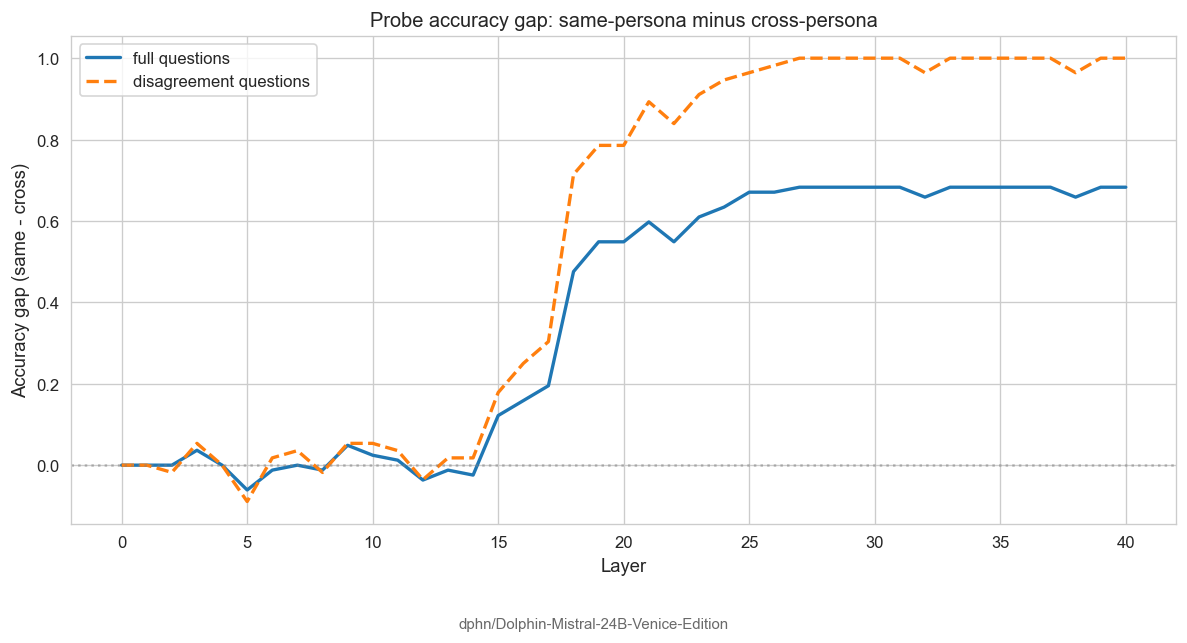

Positive gap = activations encode persona-specific answer information.
Negative gap = other persona's activations are MORE informative (unlikely).


In [23]:
# ── Probe accuracy gap: same - cross persona ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for subset, style in [("full", "-"), ("disagreement", "--")]:
    sub = probe_metrics[probe_metrics["subset"] == subset]
    if sub.empty:
        continue
    same = sub[sub["combo_type"] == "same_persona"].groupby("layer")["accuracy"].mean()
    cross = sub[sub["combo_type"] == "cross_persona"].groupby("layer")["accuracy"].mean()
    gap = same - cross
    gap = gap.dropna()
    ax.plot(gap.index, gap.values, linestyle=style, linewidth=2, label=f"{subset} questions")

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy gap (same - cross)")
ax.set_title("Probe accuracy gap: same-persona minus cross-persona")
ax.legend()
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print("Positive gap = activations encode persona-specific answer information.")
print("Negative gap = other persona's activations are MORE informative (unlikely).")

### Persona identity probe: is the persona itself encoded in activations?

A different probe: given a hidden state vector, can we tell whether it came from the conservative or progressive persona? This is a binary classification (50% chance baseline).

- **High accuracy** (near 100%) = the model's internal state is measurably different between personas at that layer. The system prompt has left a "fingerprint" in the hidden states.
- **Near chance** (50%) = the hidden states are indistinguishable between personas at that layer.

**Note:** High persona identity accuracy doesn't necessarily mean the *answer* differs — even on agreement questions, the system prompt text is different, so early layers will likely show high identity accuracy just from the prompt tokens. The interesting signal is whether identity accuracy *stays* high through the later layers where the model is computing its answer.

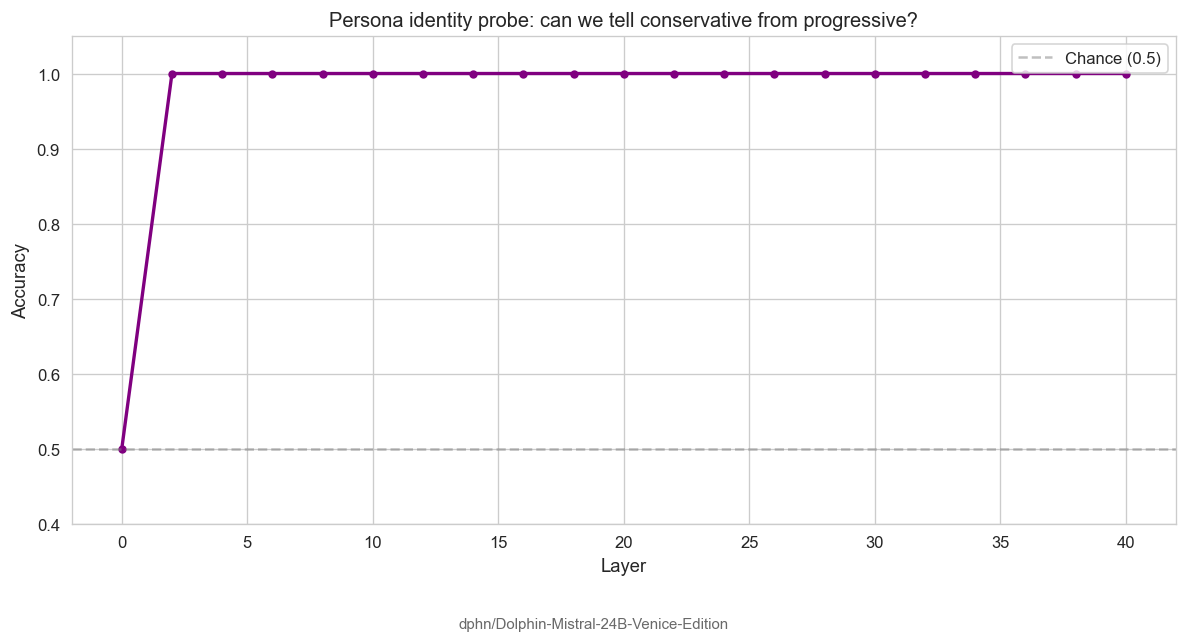

Final layer persona identification accuracy: 1.000


In [24]:
# ── Persona identity probe: can we tell WHICH persona from activations? ─
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

id_layers = sorted(set([0] + list(range(0, N_LAYERS, 2)) + [N_LAYERS - 1]))
id_results = []

rng = np.random.RandomState(42)
indices = np.arange(N_QUESTIONS)
rng.shuffle(indices)
n_train = int(0.7 * N_QUESTIONS)
train_idx_id = indices[:n_train]
test_idx_id = indices[n_train:]

for layer in id_layers:
    x1 = act_p1[:, layer, :].numpy()
    x2 = act_p2[:, layer, :].numpy()
    X_train = np.concatenate([x1[train_idx_id], x2[train_idx_id]], axis=0)
    y_train = np.array([0] * len(train_idx_id) + [1] * len(train_idx_id))
    X_test = np.concatenate([x1[test_idx_id], x2[test_idx_id]], axis=0)
    y_test = np.array([0] * len(test_idx_id) + [1] * len(test_idx_id))

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
    clf.fit(X_train_s, y_train)
    acc = clf.score(X_test_s, y_test)
    id_results.append({"layer": layer, "accuracy": acc})

id_df = pd.DataFrame(id_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(id_df["layer"], id_df["accuracy"], "o-", color="purple", linewidth=2, markersize=4)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance (0.5)")
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Persona identity probe: can we tell conservative from progressive?")
ax.legend()
ax.set_ylim(0.4, 1.05)
_model_footer(fig, MODEL_NAME)
plt.tight_layout()
plt.show()

print(f"Final layer persona identification accuracy: {id_df.iloc[-1]['accuracy']:.3f}")

## 6. Key Findings Summary

In [25]:
sep = "=" * 60
print(sep)
print("KEY FINDINGS")
print(sep)

print(f"\nModel: {MODEL_NAME}")
print(f"Questions: {N_QUESTIONS}, Layers: {N_LAYERS}, d_model: {D_MODEL}")

print(f"\n1. AGREEMENT / DISAGREEMENT")
print(f"   Overall: {n_agree}/{total} agree ({100*n_agree/total:.1f}%), "
      f"{n_disagree}/{total} disagree ({100*n_disagree/total:.1f}%)")
for _, row in cat_summary.iterrows():
    print(f"   {row['cat_short']:<20s}: {row['disagree_rate']:.0f}% disagree (n={int(row['n'])})")

print(f"\n2. LOGIT LENS \u2014 DIVERGENCE ONSET")
if len(divergence_layers) > 0:
    print(f"   Mean layer of persona divergence: {divergence_layers.mean():.1f} / {N_LAYERS-1}")
    print(f"   Median: {np.median(divergence_layers):.0f}")
    pct_early = (divergence_layers < N_LAYERS // 2).mean() * 100
    print(f"   {pct_early:.0f}% of divergences begin in first half of network")

print(f"\n3. ACTIVATION SIMILARITY")
final_cos_all = cos_sim[:, -1].mean().item()
final_cos_agree = cos_sim[agree_mask][:, -1].mean().item() if agree_mask.sum() > 0 else float('nan')
final_cos_disagree = cos_sim[disagree_mask][:, -1].mean().item() if disagree_mask.sum() > 0 else float('nan')
print(f"   Final layer cosine sim (all):          {final_cos_all:.4f}")
print(f"   Final layer cosine sim (agreement):    {final_cos_agree:.4f}")
print(f"   Final layer cosine sim (disagreement): {final_cos_disagree:.4f}")

print(f"\n4. PROBES")
last_layer = probe_metrics["layer"].max()
last_full = probe_metrics[(probe_metrics["layer"] == last_layer) & (probe_metrics["subset"] == "full")]
for _, row in last_full.iterrows():
    print(f"   Layer {int(row['layer'])} {row['combo_type']:<15s} "
          f"probe={row['probe_persona'].replace('persona_','')[:4]} "
          f"acts={row['activation_persona'].replace('persona_','')[:4]}  "
          f"acc={row['accuracy']:.3f}")

print(f"\n5. PERSONA IDENTITY")
print(f"   Final layer persona ID accuracy: {id_df.iloc[-1]['accuracy']:.3f}")

print(f"\n{sep}")
print("INTERPRETATION")
print(sep)
print("""
If cross-persona probe accuracy is NEAR same-persona accuracy:
  -> Both personas build similar internal representations
  -> Persona effect is mostly at the output layer (shallow)

If cross-persona probe accuracy is MUCH LOWER (esp. on disagreement Qs):
  -> Personas create genuinely different internal representations
  -> Persona effect is deep (affects intermediate computation)

If persona identity probe is HIGH (>>50%):
  -> The model's internal state is measurably different between personas
  -> Consistent with deep persona effects
""")

KEY FINDINGS

Model: dphn/Dolphin-Mistral-24B-Venice-Edition
Questions: 205, Layers: 41, d_model: 5120

1. AGREEMENT / DISAGREEMENT
   Overall: 75/205 agree (36.6%), 130/205 disagree (63.4%)
   Ambiguous           : 39% disagree (n=36)
   Ethics (mod)        : 56% disagree (n=36)
   Factual (ctrl)      : 0% disagree (n=35)
   Policy (high)       : 100% disagree (n=50)
   Values (high)       : 96% disagree (n=48)

2. LOGIT LENS — DIVERGENCE ONSET
   Mean layer of persona divergence: 31.9 / 40
   Median: 33
   0% of divergences begin in first half of network

3. ACTIVATION SIMILARITY
   Final layer cosine sim (all):          0.8709
   Final layer cosine sim (agreement):    0.9748
   Final layer cosine sim (disagreement): 0.8109

4. PROBES
   Layer 40 same_persona    probe=cons acts=cons  acc=1.000
   Layer 40 cross_persona   probe=cons acts=prog  acc=0.317
   Layer 40 same_persona    probe=prog acts=prog  acc=1.000
   Layer 40 cross_persona   probe=prog acts=cons  acc=0.317

5. PERSONA I